<p>
<h1><b><center></center></b></h1>
</p>
<h1><b><center>Relatividad y Gravitación</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Problem Set 2</center></b><h2>
<h3><b><center>Transformaciones de Lorentz-Einsteins</center></b><h3>
<h5><center><b>Estudiante: </b>: Jhoan Londoño Restrepo</center><h5>


A continuación se presentan un conjunto de ejercicios o problemas para resolver usando la teoría vista en las últimas lecciones del curso. Resuelva los ejercicios *a mano* y suba una versión digitalizada en el espacio del ítem respectivo en Google Classroom.

## Punto 1

Las transformaciones generalizadas de Lorentz-Einsteins (para cualquier dirección de la velocidad) fueron deducidas por Gustav Herglotz en 1911 y se escriben en notación moderna y en unidades relativistas como:

   $$
\begin{aligned}
t^{\prime} & =-\gamma\left(u_x x+u_y y+u_z z\right)+\gamma t \\
x^{\prime} & =x+\alpha u_x\left(u_x x+u_y y+u_z z\right)-\gamma u_x t \\
y^{\prime} & =y+\alpha u_y\left(u_x x+u_y y+u_z z\right)-\gamma u_y t \\
z^{\prime} & =z+\alpha u_z\left(u_x x+u_y y+u_z z\right)-\gamma u_z t \\
\alpha & =\frac{\gamma^2}{\gamma+1}, \gamma=\frac{1}{\sqrt{1-u^2}}
\end{aligned}
$$

  Demuestre que estas mismas transformaciones pueden escribirse en notación vectorial como:

  $$
\begin{aligned}
t^{\prime} & =\gamma\left(t-\vec{u} \cdot \vec{r}\right) \\
\vec{r}^{\prime} & =\vec{r}+\left(\frac{\gamma-1}{u^2} \vec{u} \cdot \vec{r}-\gamma t\right) \vec{u}
\end{aligned}
  $$
  donde para ser consistentes con la notación no hemos incluído el subíndice $L$ que usamos en otras partes.

## Punto 2

Las TLEs pueden escribirse usando notación matricial como:

   $$
   \left(\begin{array}{c}
t^{\prime} \\
x_L^{\prime} \\
y_L^{\prime} \\
z_L^{\prime}
\end{array}\right)=
\Lambda (\vec u_L)
\left(\begin{array}{c}
t \\
x_L \\
y_L \\
z_L
\end{array}\right)
   $$

  Muestre que las componentes de las TLEs generales del punto 1 son:

  $$
  \begin{aligned}
& \Lambda_{t^{\prime} t}=\gamma \\
& \Lambda_{t^{\prime} i}=\Lambda_{i^{\prime} t}=-\gamma \mathrm{u}_{\mathrm{L} i} \\
& \Lambda_{i^{\prime} j}=\delta_{\mathrm{ij}}+(\gamma-1) \mathrm{u}_{\mathrm{L} i} \mathrm{u}_{\mathrm{L} j} / \mathrm{u}_{\mathrm{L}}^2
\end{aligned}
  $$

  Muestre que la matriz, componente por componente, se puede escribir como:

   $$
   \Lambda(\vec u_L) = \left(\begin{array}{cccc}
\gamma & -\gamma u_{Lx} & -\gamma u_{Ly} & -\gamma u_{Lz} \\
-\gamma u_{Lx} & 1+\frac{\gamma^2}{1+\gamma} u_{Lx}^2 & \frac{\gamma^2}{1+\gamma} u_{Lx} u_{Ly} & \frac{\gamma^2}{1+\gamma} u_{Lx} u_{Lz} \\
-\gamma u_{Ly} & \frac{\gamma^2}{1+\gamma} u_{Lx} u_{Ly} & 1+\frac{\gamma^2}{1+\gamma} u_{Ly}^2 & \frac{\gamma^2}{1+\gamma} u_{Ly} u_{Lz} \\
-\gamma u_{Lz} & \frac{\gamma^2}{1+\gamma} u_{Lx} u_{Lz} & \frac{\gamma^2}{1+\gamma} u_{Ly} u_{Lz} & 1+\frac{\gamma^2}{1+\gamma} u_{Lz}^2
\end{array}\right)
   $$

## Punto 3

Vamos a representar gráficamente las transformaciones de velocidades. Para ello vamos a suponer que desde el origen de coordenadas del sistema del experimento (O') salen partículas con rapidez idéntica $v_L$ en todas direcciones.

  a. Escoja N direcciones del espacio y dibuje usando `quiver` (o un comando análogo) los vectores de velocidad correspondientes a cada dirección.

  b. Aplique las reglas de conversión de velocidades en la configuración estándar para encontrar las componentes de la velocidad medidas en el laboratorio. El gráfico se debe parece a la figura abajo.

  c. Construya un código interactivo que le permita modificar tanto la velocidad relativa entre los sistemas de referencia $u_L$ y la rapidez de las partículas $v_L$.

  d. Escoja $v_L=1$ (fotones). ¿Qué diferencias observa entre el caso de $v_L<1$ y el caso de los fotones?.



  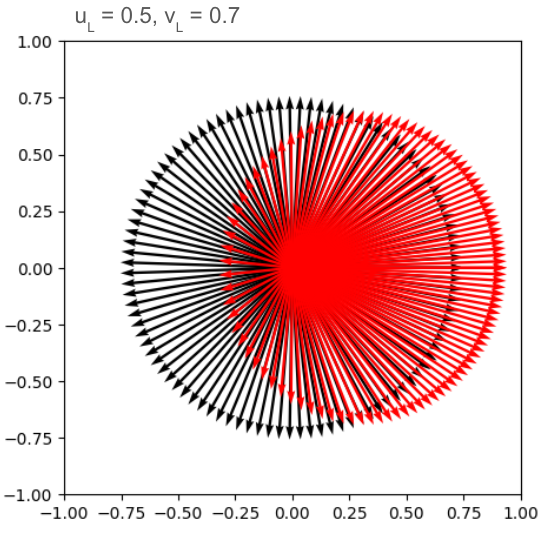

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from ipywidgets import interact

In [3]:
u0 = 0.5    # [c] - Velocidad relativa
vp0 = 0.7   # [c] - Velocidad de las partículas

@interact(u=(0,0.99,0.01), vp=(0,1,0.01))
def TLEvelocity(u=u0, vp=vp0):
  gamma = 1/(1-u**2)**0.5
  N = 80   # Número de direcciones

  angles = np.linspace(0, 2*np.pi, N, endpoint=False)

  # Componentes de la velocidad de las partículas en el sistema propio
  # Misma magnitud pero diferentes direcciones
  vxp = vp*np.cos(angles)
  vyp = vp*np.sin(angles)

  # Velocidades de las parts de O' vistas desde O
  vx = (vxp + u)/(1+u*vxp)
  vy = vyp/(gamma*(1+u*vxp))

  # Gráfico
  fig = plt.figure(figsize=(7, 7))
  plt.title("TLE's de velocidades: Fuente en O' vista desde O' y O")

  plt.quiver(np.zeros(N), np.zeros(N), vxp, vyp, scale=1, scale_units='xy', angles='xy')
  plt.quiver(np.zeros(N), np.zeros(N), vx, vy, scale=1, scale_units='xy', angles='xy', color='magenta')
  plt.quiver(0, 0, u, 0, scale=1, scale_units='xy', angles='xy', color='lightcyan')

  plt.xlabel(r"Velocidad en $x$ [c]")
  plt.ylabel(r"Velocidad en $y$ [c]")
  plt.xlim(-1, 1)
  plt.ylim(-1, 1)
  plt.legend(["Respecto a O'", "Respecto a O", r"Velocidad Relativa: $\vec{u}$"])

  plt.show()
  fig.tight_layout()

interactive(children=(FloatSlider(value=0.5, description='u', max=0.99, step=0.01), FloatSlider(value=0.7, des…

## Punto 4

En clase calculamos la magnitud de la aberración cuando una estrella se encuentra en el mismo meridiano eclíptico en el que está el vector velocidad de la Tierra. Vamos a calcular la magnitud de la aberración cuando la estrella está en una posición arbitraria de la esfera celeste en longitud eclíptica $\lambda$ y latitud eclíptica $\beta$. Para ello:

   a. Escriba explícitamenete las componentes $x$, $y$, $z$ de la velocidad de un fotón procedente de la estrella, en el sistema de referencia del baricentro del sistema solar y como función de las coordenadas eclípticas.

   b. En un momento dado del año las componentes de la velocidad de la Tierra son $u_x$ y $u_y$ (que pueden calcularse usando `SPICE` o `astroquery`). Encuentre expresiones para las coordenadas eclípticas aparentes $\lambda'$ y $\beta'$ para una estrella usando la ley generalizada de transformación de velocidades.

   c. Escoja una estrella que pertenezca a la constelación de su signo zodiacal. Averigue sus coordenadas eclípticas respecto al baricentro del sistema solar. Calcule, usando las expresiones en b, la diferencia entre las coordenadas eclípticas aparente y las referidas al baricentro en la fecha de su cumpleaños en 2024.

   d. (Opcional) Grafique las coordenadas eclípticas aparentes durante un año completo para la estrella elegida.

**Estrella:**

* Constelación de Virgo y sector de 150° a 180°.

* Estrella $\alpha$ Virginis, comúnmente llamadas como Espiga o Spica. Es la más brillante de la constelación con magnitud aparente +1,0, es una estrella binaria espectroscópica con las dos componentes muy próximas entre sí.

In [ ]:
!python -m pip install astroquery astropy &> /dev/null

In [ ]:
from astroquery.jplhorizons import Horizons
from astropy.time import Time

In [ ]:
''' ============== Coordenadas eclípticas de una estrella ============== '''

# ============= Código extraído de ChatGPT =============
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord, GeocentricTrueEcliptic, BarycentricTrueEcliptic
import astropy.units as u
from astropy.coordinates import Galactic, FK5

def get_ecliptic_coordinates(star_name):
    # Consultar las coordenadas ecuatoriales de la estrella usando SIMBAD
    Simbad.add_votable_fields('ra', 'dec')

    # Obtener los resultados de la consulta
    result_table = Simbad.query_object(star_name)

    if result_table is None:
        print(f"No se encontraron datos para la estrella: {star_name}")
        return None

    # Extraer las coordenadas ecuatoriales (RA, DEC) de la estrella
    ra = result_table['RA'][0]
    dec = result_table['DEC'][0]

    # Convertir las coordenadas RA y DEC en un objeto SkyCoord
    coord = SkyCoord(ra=ra, dec=dec, unit=(u.hourangle, u.deg), frame='icrs')

    # Convertir las coordenadas a eclípticas
    # coords_bary = coord.transform_to(BarycentricTrueEcliptic())
    coords_bary = coord.barycentrictrueecliptic
    coords_earth = coord.geocentrictrueecliptic

    return coords_bary

# Coordenadas eclípticas de la estrella Spica de la constelación de Virgo
#
coords_bary = get_ecliptic_coordinates("spica")   # [°]
coords_bary

<SkyCoord (BarycentricTrueEcliptic: equinox=J2000.000): (lon, lat) in deg
    (203.83748901, -2.05448733)>

In [ ]:
c = 2.998e8     # [m/s] - Velocidad de la luz
AU = 1.496e11   # [m] - Unidad Astronómica
dia = 86400     # [s] - día

''' --------------------------------------------------------------------- '''
date0 = "2024-09-14"
date = Time(date0)
jd_date = date.jd

data = Horizons(id=399, location='@0', epochs=jd_date)
datap = data.vectors()
datap = datap.to_pandas()

# Componentes de velocidad de la Tierra en dicho día respecto al baricentro del sistema solar
u = np.array(datap[["vx", "vy", "vz"]])[0]     # AU/d
u[2] = 0
u = u*AU/dia   # [m/s]

# Pasamos la velocidad de la Tierra a unidades canónicas
ul = u/c    # [c]
ul

array([1.33534341e-05, 9.78064465e-05, 0.00000000e+00])

In [ ]:
# Coordenadas eclípticas de la estrella Spica de la constelación de Virgo
lonE = coords_bary.lon.value    # [°]
latE = coords_bary.lat.value

lonE, latE = lonE*np.pi/180, latE*np.pi/180   # [rad]

''' Un fotón sale de la estrella y viene hacia el observador ubicado en el baricentro del Sistema Solar '''
# Componentes de la velocidad [c]
vlx = np.cos(latE)*np.cos(lonE)
vly = np.cos(latE)*np.sin(lonE)
vlz = np.sin(latE)
vl = np.array([vlx, vly, vlz])

# Transformación de las velocidades al sistema de referencia desde la Tierra
def velocity_transf(ul):
  norm_ul = np.linalg.norm(ul)
  gamma = 1/(1-norm_ul**2)**0.5

  den = gamma*(1 - ul@vl)
  vlp = (vl + ((gamma-1)/norm_ul**2*ul@vl - gamma)*ul)/den

  vlxp, vlyp, vlzp = vlp[0], vlp[1], vlp[2]

  latEp = np.arcsin(vlzp)         # [-pi/2, pi/2] por el rango de la función arcsin(x)
  lonEp = np.arctan2(vlyp, vlxp)  # [-pi, pi]
  if lonEp < 0:
      lonEp += 2*np.pi    # Ajuste para el rango [0, 2pi]

  return lonEp, latEp

lonEp, latEp = velocity_transf(ul)
lonEp*180/np.pi, latEp*180/np.pi

(203.84230863398543, -2.0543810462888317)

In [ ]:
print('======= Estrella Spica, Constelación de Virgo =======')
print('==============  Coordenadas eclípticas ==============\n')
print("Respecto al baricentro del sistema solar:")
print("\t* Longitud eclíptica (λ): %.5lf °" %(lonE*180/np.pi))
print("\t* Latitud eclíptica (β): %.5lf °" %(latE*180/np.pi))

print(f"\nRespecto a la Tierra en la fecha {date0}:")
print("\t* Longitud eclíptica (λ'): %.5lf °" %(lonEp*180/np.pi))
print("\t* Latitud eclíptica (β'): %.5lf °" %(latEp*180/np.pi))

print("\nDiferencia entre las coordenadas:")
dlonE = ((lonEp - lonE)*180/np.pi)*3600    # ['']
dlatE = ((latEp - latE)*180/np.pi)*3600
print("\t* Longitud eclíptica (λ' - λ) = %.5lf '' " %dlonE)
print("\t* Latitud eclíptica (β' - β) = %.5lf '' " %dlatE)

======= Estrella Spica, Constelación de Virgo =======
==============  Coordenadas eclípticas ==============

Respecto al baricentro del sistema solar:
	* Longitud eclíptica (λ): 203.83749 °
	* Latitud eclíptica (β): -2.05449 °

Respecto a la Tierra en la fecha 2024-09-14:
	* Longitud eclíptica (λ'): 203.84231 °
	* Latitud eclíptica (β'): -2.05438 °

Diferencia entre las coordenadas:
	* Longitud eclíptica (λ' - λ) = 17.35064 '' 
	* Latitud eclíptica (β' - β) = 0.38263 '' 


#### Coordenadas eclípticas aparentes durante el año 2023

In [ ]:
# =========================
dates = {'start': '2023-01-01', 'stop': '2023-12-31', 'step': '1d'}

datas = Horizons(id=399, location='@0', epochs=dates)
datasp = datas.vectors()
datasp = datasp.to_pandas()

# # Componentes de velocidad de la Tierra en dicho día respecto al baricentro del sistema solar
us = np.array(datasp[["vx", "vy", "vz"]])     # AU/d
us = us*AU/dia   # [m/s]
us[:, 2] = 0

# Pasamos la velocidad de la Tierra a unidades canónicas
uls = us/c    # [c]

# Transformación de las velocidades al sistema de referencia desde la Tierra
lonEs = np.zeros(len(uls))
latEs = np.zeros(len(uls))
fechas = np.zeros_like(datasp.datetime_str)
fechas2 = np.array(['']*len(uls), dtype=object)

for i in range(len(uls)):
  lonE, latE = velocity_transf(uls[i])

  lonEs[i] = lonE
  latEs[i] = latE

  fecha = datasp.datetime_str[i].split()[1][5:]
  fechas[i] = fecha
  if int(fecha.split('-')[1]) == 1:
    fechas2[i] = fecha

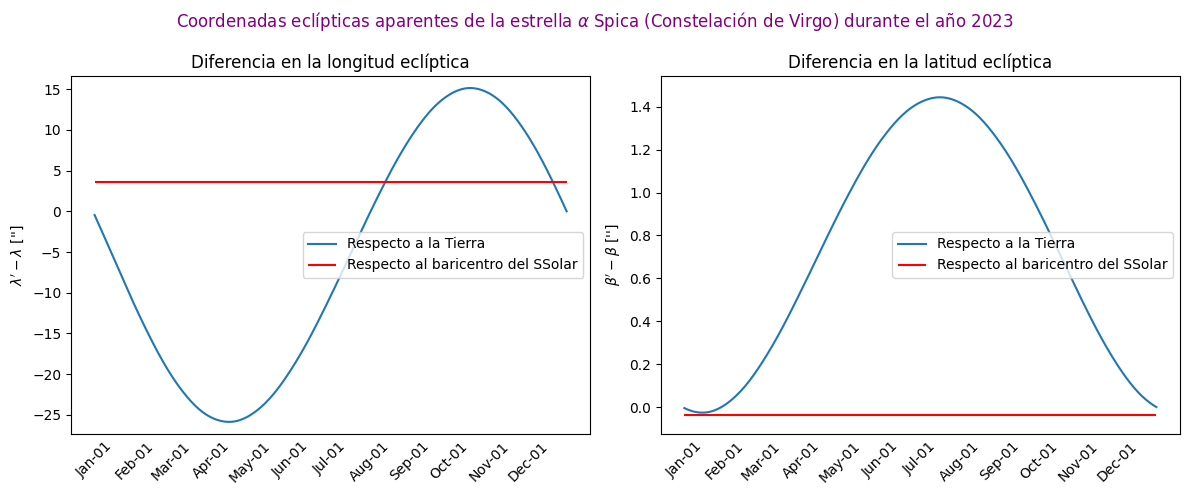

In [ ]:
# Gráfico
fig, [axlon, axlat] = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(r"Coordenadas eclípticas aparentes de la estrella $\alpha$ Spica (Constelación de Virgo) durante el año 2023", color='purple')

dlonEs = ((lonEs - lonE)*180/np.pi)*3600    # ['']
dlatEs = ((latEs - latE)*180/np.pi)*3600
axlon.plot(fechas, dlonEs, label='Respecto a la Tierra')
axlon.hlines(lonE, fechas[0], fechas[-1], color='red', label='Respecto al baricentro del SSolar')
axlat.plot(fechas, dlatEs, label='Respecto a la Tierra')
axlat.hlines(latE, fechas[0], fechas[-1], color='red', label='Respecto al baricentro del SSolar')

axlon.set_title("Diferencia en la longitud eclíptica")
axlon.set_ylabel(r"$\lambda' - \lambda$ ['']")
axlon.set_xticks(fechas2)
axlon.tick_params(axis='x', rotation=45, which='both', length=0)
axlon.set_ylim(min(dlonEs)-1.5, max(dlonEs)+1.5)
axlon.legend(loc='center right')

axlat.set_title("Diferencia en la latitud eclíptica")
axlat.set_ylabel(r"$\beta' - \beta$ ['']")
axlat.set_xticks(fechas2)
axlat.tick_params(axis='x', rotation=45, which='both', length=0)
axlat.set_ylim(min(dlatEs)-0.1, max(dlatEs)+0.1)
axlat.legend(loc='center right')

fig.tight_layout()

## Punto 5

El crucero espacial de la **Federación**, *Execrable*, está flotando en reposo en territorio de la Federación con respecto a la frontera del espacio Klingon, que está a 6.0 min-luz de distancia en la dirección +x.

  Súbtamente, una nave de guerra de Klingon vuela pasando al crucero en la dirección de la frontera con una rapidez $u_L = 3/5$. Llame a esto evento A, y defina el tiempo cero en los marcos de referencia de Klingon y del crucero.
  
  En $t_B$ = 5.0 min de acuerdo con relojes del crucero, la nave de Klingon emite un estallido perturbador de partida (evento B) que viaja con la rapidez de la luz hacia el crucero.
  
  El estallido golpea al crucero y lo incapacita (evento C) y un poco más tarde (de acuerdo con mediciones de radar del crucero) la nave de Klingon cruza la frontera hacia su territorio (evento D).

  a. Dibuje un diagrama espacio-tiempo de dos observadores de la situación, tomando al crucero para definir al sistema de referencia del laboratorio (O) y a la nave de guerra de Klingon para definir el sistema de referencia del experimento (O'). Dibuje y etiquete las líneas de mundo del crucero, la frontera de territorio Klingon, la nave de guerra de Klingon y el estallido perturbador. Dibuje y etiquete los eventos A, B, C y D como puntos sobre su diagrama.

  b. ¿Cuándo golpea el estallido perturbador y cuándo pasan los Klingon hacia su propio territorio, de acuerdo con los relojes en el marco del crucero? Responda mediante la lectura de los tiempos de dichos eventos directamente del diagrama.

  c. El Tratado Klingon-Federación establece que es ilegal que una nave Klingon en territorio de la Federación dañe propiedad de ésta. Cuando el caso llega a una corte interestelar, los emisarios de Klingon afirman que están dentro de la ley: de acuerdo con mediciones realizadas en su marco de referencia, el daño al Execrable ocurrió después de que habían cruzado hacia territorio Klingon: por lo tanto, ellos no estaban en territorio de la Federación en ese momento. ¿El evento C (el estallido perturbador golpea al Execrable) en realidad ocurrió después que el evento D (la nave de Klingon cruza la frontera) en el marco de estos últimos? Responda la pregunta utilizando su diagrama de dos observadores y compruebe su trabajo con las ecuaciones de transformación de Lorentz.

**NOTAS**: Debe dibujar a mano los diagramas espacio temporales.